In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob

In [35]:
df = pd.read_csv("Reviews.csv")

df = df.head(5000)

print("Dataset Shape:", df.shape)

df.head(10)

Dataset Shape: (5000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [37]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(5000, 10)


In [38]:
print(df.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [39]:
df = df[['Text','Score']]

df.head()

,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [40]:
df.isnull().sum()

,0
Text,0
Score,0


In [41]:
df.dropna(subset=['Text'], inplace=True)

print(df.shape)

(5000, 2)


In [42]:
df.drop_duplicates(subset=['Text'], inplace=True)

print(df.shape)

(4984, 2)


In [43]:
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['Polarity'] = df['Text'].apply(get_polarity)

df.head()

,Text,Score,Polarity
0,I have bought several of the Vitality canned d...,5,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333
2,This is a confection that has been around a fe...,4,0.133571
3,If you are looking for the secret ingredient i...,2,0.166667
4,Great taffy at a great price. There was a wid...,5,0.483333


In [44]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Polarity'].apply(get_sentiment)

df[['Text','Sentiment']].head()

,Text,Sentiment
0,I have bought several of the Vitality canned d...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,This is a confection that has been around a fe...,Positive
3,If you are looking for the secret ingredient i...,Positive
4,Great taffy at a great price. There was a wid...,Positive


In [45]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,4403
Negative,501
Neutral,80


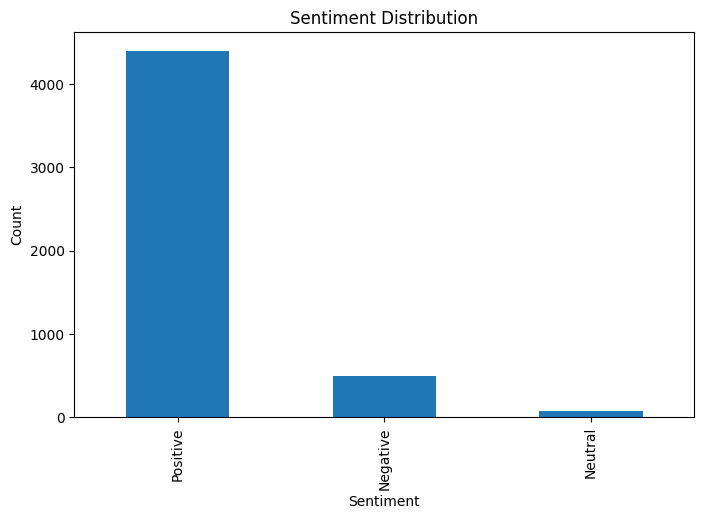

In [46]:
counts = df['Sentiment'].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("sentiment_bar.png")

plt.show()

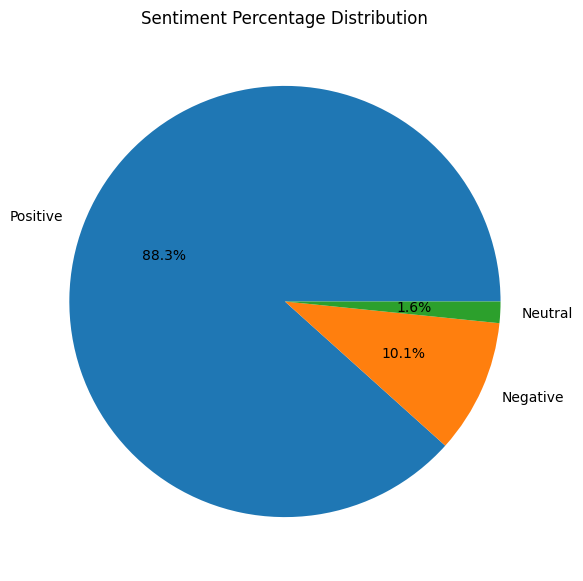

In [47]:
plt.figure(figsize=(7,7))

counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title("Sentiment Percentage Distribution")

plt.savefig("sentiment_pie.png")

plt.show()

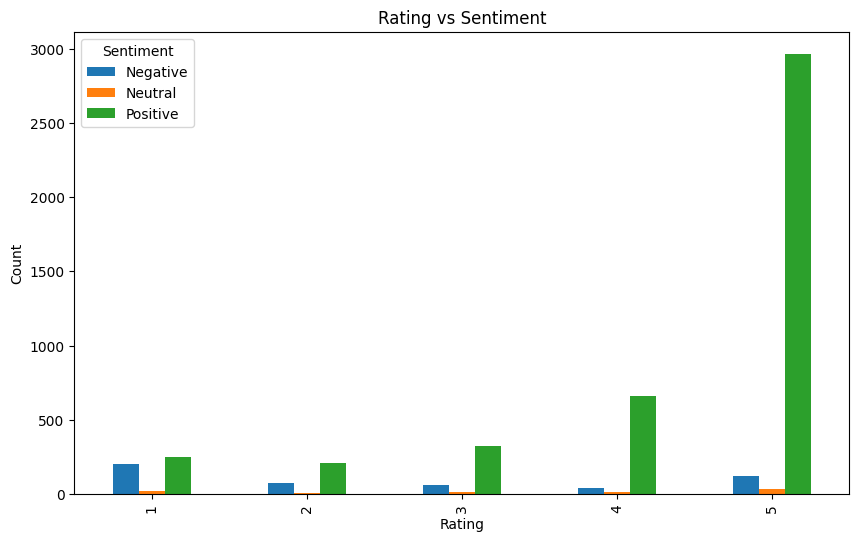

In [48]:
pd.crosstab(
    df['Score'],
    df['Sentiment']
).plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("custom_chart.png")

plt.show()

In [49]:
positive_percentage = (
    (df['Sentiment'] == "Positive")
    .mean() * 100
)

print("Positive Percentage:")
print(round(positive_percentage,2))

Positive Percentage:
88.34


In [50]:
negative_reviews = df[df['Sentiment']=="Negative"]

negative_reviews['Text'].head(10)

,Text
1,Product arrived labeled as Jumbo Salted Peanut...
14,The Strawberry Twizzlers are my guilty pleasur...
50,"This oatmeal is not good. Its mushy, soft, I d..."
52,This wasn't in stock the last time I looked. I...
62,Arrived in 6 days and were so stale i could no...
67,"I purchased the Mango flavor, and to me it doe..."
69,this was sooooo deliscious but too bad i ate e...
94,This is the same food we get at pet store. But...
98,My English Bulldog had skin allergies the summ...
99,I fed this to my Golden Retriever and he hated...


In [51]:
print(df['Sentiment'].value_counts())

print("\nPercentage Distribution")

print(
    round(
        df['Sentiment']
        .value_counts(normalize=True)*100,
        2
    )
)

Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

Percentage Distribution
Sentiment
Positive    88.34
Negative    10.05
Neutral      1.61
Name: proportion, dtype: float64
